# 실전 프로젝트 1차 eda

In [73]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 데이터 로드

In [74]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df_portfolio = pd.read_csv("data/portfolio.csv", index_col=0)
df_profile = pd.read_csv("data/profile.csv", index_col=0)
df_transcript = pd.read_csv("data/transcript.csv", index_col=0)

In [75]:
# ============================================================
# 2. 데이터 기본 구조 확인
# ============================================================
print("===== 기본 크기 확인 =====")
print("\n[portfolio]")
print("shape :", df_portfolio.shape)
display(df_portfolio.head())
print()

print("[profile]")
print("shape :", df_profile.shape)
display(df_profile.head())
print()

print("[transcript]")
print("shape :", df_transcript.shape)
display(df_transcript.head())
print()


===== 기본 크기 확인 =====

[portfolio]
shape : (10, 6)


,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7



[profile]
shape : (17000, 5)


,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN



[transcript]
shape : (306534, 4)


,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


# 1차 EDA를 통한 결측치 및 이상치 확인

### 필요 함수

In [76]:
# 컬럼 정보 간단 표현
def check_basic_info(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 컬럼 정보 / 결측치 확인 정보 요약")
    print(f"{'='*80}\n")
    
    # 1. 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df.shape[0], df.shape[1], df.duplicated().sum()]
    })
    
    # 2. 컬럼별 요약
    summary_df = pd.DataFrame({
        '데이터타입': df.dtypes.astype(str),
        '행 개수': df.count(),
        '행 비율(%)': (df.count() / len(df) * 100).round(2),
        '결측치 개수': df.isnull().sum(),
        '결측치 비율(%)': (df.isnull().sum() / len(df) * 100).round(2),
        '고유값 개수': df.nunique(dropna=True)
    })
    
    # 3. 보기 좋게 정렬
    summary_df = summary_df.sort_values(
        by=['결측치 개수', '고유값 개수'],
        ascending=[False, False]
    )
    
    print("[전체 요약]")
    display(overview_df)
    
    print("[컬럼별 요약]")
    display(summary_df)


# 기술통계 총합
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 관련 데이터 기초통계량")
    print(f"{'='*80}\n")
    
    # 1-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 1-2. 기초 통계량
    stats_df = df_copied.describe().T
    
    # 1-4. 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수', # 결측치가 아닌 값의 개수
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
    }, inplace=True)
    
    display(stats_df)


In [77]:
# 컬럼 분포 확인
def check_category_summary(df, df_name, col_name):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 {col_name} 범주 확인")
    print(f"{'='*80}\n")
    
    summary_df = df[col_name].value_counts(dropna=False).reset_index()
    summary_df.columns = [col_name, '개수']
    summary_df['비율(%)'] = (summary_df['개수'] / len(df) * 100).round(2)
    
    display(summary_df.head(10))

In [78]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. 히스토그램 시각화 함수
# ============================================================
def plot_histograms(df, cols, group_title, n_cols=3, bins=30):
    
    n_plots = len(cols)
    n_rows = math.ceil(n_plots / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    
    # axes를 1차원 배열로 변환
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.histplot(
            data=df,
            x=col,
            bins=bins,
            kde=True,
            color="#4E4CB0",
            alpha=0.4,
            ax=axes[i]
        )
        axes[i].set_title(f"{col} 분포", fontsize=11, fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")
    
    # 남는 subplot 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(f"[{group_title}] 히스토그램 분포 확인", fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# ============================================================
# 2. 박스플롯 시각화 함수
# ============================================================
def plot_boxplots(df, cols, group_title, n_cols=3):
    
    n_plots = len(cols)
    n_rows = math.ceil(n_plots / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3.5))
    
    # axes를 1차원 배열로 변환
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.boxplot(
            x=df[col],
            color="#DD5252",
            ax=axes[i]
        )
        axes[i].set_title(f"{col} 박스플롯", fontsize=11, fontweight="bold")
        axes[i].set_xlabel(col)
    
    # 남는 subplot 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(f"[{group_title}] 박스플롯 이상치 확인", fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## df_portfolio

In [79]:
check_basic_info(df_portfolio, "portfolio")


portfolio의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,10
1,열 개수,6
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
id,str,10,100.0,0,0.0,10
reward,int64,10,100.0,0,0.0,5
difficulty,int64,10,100.0,0,0.0,5
duration,int64,10,100.0,0,0.0,5
channels,str,10,100.0,0,0.0,4
offer_type,str,10,100.0,0,0.0,3


In [80]:
print("df_portfolio 중복 행 개수:", df_portfolio.duplicated().sum())
print("portfolio id 중복:", df_portfolio["id"].duplicated().sum())

# 특절 컬럼 제외 중복 확인
print("id 제외 중복 행 개수:", df_portfolio.drop(columns=["id"], errors="ignore").duplicated().sum())

df_portfolio 중복 행 개수: 0
portfolio id 중복: 0
id 제외 중복 행 개수: 0


In [81]:
create_statistics_summary(df_portfolio, 'df_portfolio')


df_portfolio 관련 데이터 기초통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값
reward,10.0,4.2,3.583915,0.0,2.0,4.0,5.0,10.0
difficulty,10.0,7.7,5.831905,0.0,5.0,8.5,10.0,20.0
duration,10.0,6.5,2.321398,3.0,5.0,7.0,7.0,10.0


In [82]:
check_category_summary(df_portfolio, "portfolio", "reward")
check_category_summary(df_portfolio, "portfolio", "channels")
check_category_summary(df_portfolio, "portfolio", "difficulty")
check_category_summary(df_portfolio, "portfolio", "duration")
check_category_summary(df_portfolio, "portfolio", "offer_type")
check_category_summary(df_portfolio, "portfolio", "id")


portfolio의 reward 범주 확인



,reward,개수,비율(%)
0,5,3,30.0
1,10,2,20.0
2,0,2,20.0
3,2,2,20.0
4,3,1,10.0



portfolio의 channels 범주 확인



,channels,개수,비율(%)
0,"['web', 'email', 'mobile', 'social']",4,40.0
1,"['web', 'email', 'mobile']",3,30.0
2,"['email', 'mobile', 'social']",2,20.0
3,"['web', 'email']",1,10.0



portfolio의 difficulty 범주 확인



...

,duration,개수,비율(%)
0,7,4,40.0
1,5,2,20.0
2,10,2,20.0
3,4,1,10.0
4,3,1,10.0



portfolio의 offer_type 범주 확인



,offer_type,개수,비율(%)
0,bogo,4,40.0
1,discount,4,40.0
2,informational,2,20.0



portfolio의 id 범주 확인



,id,개수,비율(%)
0,ae264e3637204a6fb9bb56bc8210ddfd,1,10.0
1,4d5c57ea9a6940dd891ad53e9dbe8da0,1,10.0
2,3f207df678b143eea3cee63160fa8bed,1,10.0
3,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,10.0
4,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,10.0
5,2298d6c36e964ae4a3e7e9706d1fb8c2,1,10.0
6,fafdcd668e3743c1bb461111dcafc2a4,1,10.0
7,5a8bc65990b245e5a138643cd4eb9837,1,10.0
8,f19421c1d4aa40978ebb69ca19b0e20d,1,10.0
9,2906b810c7d4411798c6938adc9daaa5,1,10.0


In [83]:
print("="*60)
print("reward, difficulty, duration 표 비교")
print("="*60)

display(
    df_portfolio[["id", "offer_type", "reward", "difficulty", "duration", "channels"]]
    .sort_values(by=["offer_type", "reward", "difficulty", "duration"])
    .reset_index(drop=True)
)

reward, difficulty, duration 표 비교


,id,offer_type,reward,difficulty,duration,channels
0,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5,5,5,"['web', 'email', 'mobile', 'social']"
1,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5,5,7,"['web', 'email', 'mobile']"
2,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10,10,5,"['web', 'email', 'mobile', 'social']"
3,ae264e3637204a6fb9bb56bc8210ddfd,bogo,10,10,7,"['email', 'mobile', 'social']"
4,2906b810c7d4411798c6938adc9daaa5,discount,2,10,7,"['web', 'email', 'mobile']"
5,fafdcd668e3743c1bb461111dcafc2a4,discount,2,10,10,"['web', 'email', 'mobile', 'social']"
6,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,3,7,7,"['web', 'email', 'mobile', 'social']"
7,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,5,20,10,"['web', 'email']"
8,5a8bc65990b245e5a138643cd4eb9837,informational,0,0,3,"['email', 'mobile', 'social']"
9,3f207df678b143eea3cee63160fa8bed,informational,0,0,4,"['web', 'email', 'mobile']"


### 이상치 및 결측치 확인

행수가 10개이기 때문에 이상치 확인 (박스플롯, 히스토그램은 의미가 없음)

## df_profile

In [84]:
check_basic_info(df_profile, "profile")


profile의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,17000
1,열 개수,5
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
income,float64,14825,87.21,2175,12.79,91
gender,str,14825,87.21,2175,12.79,3
id,str,17000,100.00,0,0.00,17000
became_member_on,int64,17000,100.00,0,0.00,1716
age,int64,17000,100.00,0,0.00,85


In [85]:
# 가입일 datetime 변환
df_profile["became_member_on"] = pd.to_datetime(
    df_profile["became_member_on"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

In [86]:
# 변환 확인
display(df_profile.dtypes)
df_profile.head()

gender                         str
age                          int64
id                             str
became_member_on    datetime64[us]
income                     float64
dtype: object

,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,2017-02-12,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,2018-07-12,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,2017-08-04,NaN


In [87]:
print("df_profile 중복 행 개수:", df_profile.duplicated().sum())
print("profile id 중복:", df_profile["id"].duplicated().sum())

# 특절 컬럼 제외 중복 확인
print("중복 행 개수:", df_profile.drop(columns=["id"], errors="ignore").duplicated().sum())

df_profile 중복 행 개수: 0
profile id 중복: 0
중복 행 개수: 1237


문제라 보기엔 어려움

서로 다른 고객이 같은 정보의 조합을 가질수 있기 때문

In [88]:
create_statistics_summary(df_profile, 'df_profile')


df_profile 관련 데이터 기초통계량



,개수,평균,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,표준편차
age,17000.0,62.531412,18.0,45.0,58.0,73.0,118.0,26.73858
became_member_on,17000,2017-02-23 13:12:10.164706,2013-07-29 00:00:00,2016-05-26 00:00:00,2017-08-02 00:00:00,2017-12-30 00:00:00,2018-07-26 00:00:00,NaN
income,14825.0,65404.991568,30000.0,49000.0,64000.0,80000.0,120000.0,21598.29941


In [89]:
check_category_summary(df_profile, "profile", "gender")
check_category_summary(df_profile, "profile", "age")
# check_category_summary(df_profile, "profile", "id")  id는 고객 고유값이라 의미 없음
check_category_summary(df_profile, "profile", "became_member_on")
check_category_summary(df_profile, "profile", "income")


profile의 gender 범주 확인



,gender,개수,비율(%)
0,M,8484,49.91
1,F,6129,36.05
2,NaN,2175,12.79
3,O,212,1.25



profile의 age 범주 확인



,age,개수,비율(%)
0,118,2175,12.79
1,58,408,2.40
2,53,372,2.19
3,51,363,2.14
4,59,359,2.11
5,54,359,2.11
6,57,353,2.08
7,52,351,2.06
8,55,350,2.06
9,56,342,2.01



profile의 became_member_on 범주 확인



,became_member_on,개수,비율(%)
0,2017-12-07,43,0.25
1,2017-08-19,42,0.25
2,2017-10-07,40,0.24
3,2017-11-13,39,0.23
4,2018-01-25,38,0.22
5,2017-08-15,38,0.22
6,2017-09-28,38,0.22
7,2017-10-10,37,0.22
8,2017-11-21,36,0.21
9,2018-05-01,35,0.21



profile의 income 범주 확인



,income,개수,비율(%)
0,NaN,2175,12.79
1,73000.0,314,1.85
2,72000.0,297,1.75
3,71000.0,294,1.73
4,57000.0,288,1.69
5,53000.0,282,1.66
6,74000.0,282,1.66
7,52000.0,281,1.65
8,56000.0,281,1.65
9,54000.0,272,1.60


### 이상치 및 결측치 확인

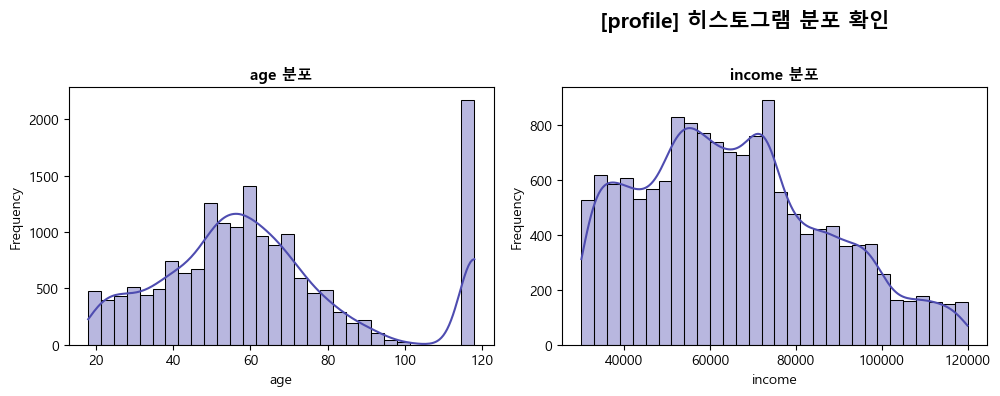

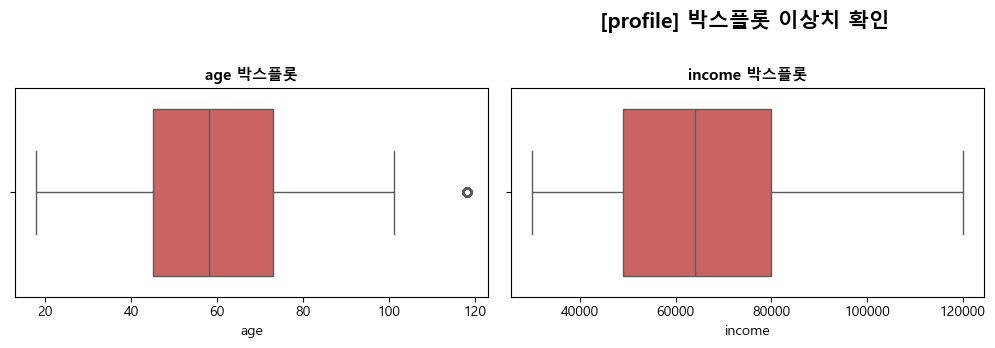

In [90]:
# 히스토그램 & 박스플롯
profile_cols = ["age", "income"]

plot_histograms(df_profile, profile_cols, "profile")
plot_boxplots(df_profile, profile_cols, "profile")

In [91]:
# 이상치 확인
# age=118 확인 (결측 대체값 후보)
print("\n[나이 분포 상위 10개]")
print(df_profile["age"].value_counts().head(10))


[나이 분포 상위 10개]
age
118    2175
58      408
53      372
51      363
59      359
54      359
57      353
52      351
55      350
56      342
Name: count, dtype: int64


In [92]:
# 결측값 확인
print("gender 결측치 개수:", (df_profile["gender"].isnull()).sum())
print("income 결측치 개수:", (df_profile["income"].isnull()).sum())

gender 결측치 개수: 2175
income 결측치 개수: 2175


In [93]:
print("gender 결측이면서 age == 118 인 개수:", (df_profile["gender"].isnull() & (df_profile["age"] == 118)).sum())
print("income 결측이면서 age == 118 인 개수:", (df_profile["income"].isnull() & (df_profile["age"] == 118)).sum())
print("gender 결측이면서, income 결측이면서, age == 118 인 개수:", (df_profile["gender"].isnull() & df_profile["income"].isnull() & (df_profile["age"] == 118)).sum())

gender 결측이면서 age == 118 인 개수: 2175
income 결측이면서 age == 118 인 개수: 2175
gender 결측이면서, income 결측이면서, age == 118 인 개수: 2175


## df_transcript 

In [94]:
check_basic_info(df_transcript, "transcript")


transcript의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,306534
1,열 개수,4
2,중복 행 개수,397


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
person,str,306534,100.0,0,0.0,17000
value,str,306534,100.0,0,0.0,5121
time,int64,306534,100.0,0,0.0,120
event,str,306534,100.0,0,0.0,4


In [95]:
print("df_transcript 중복 행 개수:", df_transcript.duplicated().sum())

display(df_transcript[df_transcript.duplicated()])

df_transcript 중복 행 개수: 397


,person,event,value,time
66123,3dde94fa581145cb9f206624f1a94d5a,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,168
66783,e9fb6ed2cecb4980ba98c86abc9c91e3,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,168
67614,a7dc060f6fc94ca7bf71fbb188187dca,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,168
68562,30478a4c1e884a63a822aa87b833ed7a,offer completed,{'offer_id': '2298d6c36e964ae4a3e7e9706d1fb8c2...,168
69218,84fb57a7fe8045a8bf6236738ee73a0f,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,168
...,...,...,...,...
297625,6ba2450a438540999e633a5d99c7c7a0,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,672
299471,f39fe7ea4e5946378e6d224504b77797,offer completed,{'offer_id': '0b1e1539f2cc45b7b9fa7c272da2e1d7...,684
304756,0785f1fce0b04ba08e01c7d2ebab4917,offer completed,{'offer_id': '0b1e1539f2cc45b7b9fa7c272da2e1d7...,708
305551,b7e216b6472b46648272c29a52a86702,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,714


transcript에서는 완전 동일한 중복 로그가 397건 존재하며, 모두 offer completed 이벤트에서 발생했다.\
이는 향후 영향을 줄수 있기 때문에 중복 제거 여부를 검토할 필요가 있다.



In [96]:
print("전체 중복 행 개수:", df_transcript.duplicated().sum())
print(df_transcript[df_transcript.duplicated()]["event"].value_counts())

display(df_transcript[df_transcript.duplicated()].head())

전체 중복 행 개수: 397
event
offer completed    397
Name: count, dtype: int64


,person,event,value,time
66123,3dde94fa581145cb9f206624f1a94d5a,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,168
66783,e9fb6ed2cecb4980ba98c86abc9c91e3,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,168
67614,a7dc060f6fc94ca7bf71fbb188187dca,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,168
68562,30478a4c1e884a63a822aa87b833ed7a,offer completed,{'offer_id': '2298d6c36e964ae4a3e7e9706d1fb8c2...,168
69218,84fb57a7fe8045a8bf6236738ee73a0f,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,168


In [97]:
create_statistics_summary(df_transcript, 'df_transcript')


df_transcript 관련 데이터 기초통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값
time,306534.0,366.38294,200.326314,0.0,186.0,408.0,528.0,714.0


In [98]:
check_category_summary(df_transcript, "transcript", "person")
check_category_summary(df_transcript, "transcript", "event")
check_category_summary(df_transcript, "transcript", "value")
check_category_summary(df_transcript, "transcript", "time")


transcript의 person 범주 확인



,person,개수,비율(%)
0,94de646f7b6041228ca7dec82adb97d2,51,0.02
1,8dbfa485249f409aa223a2130f40634a,49,0.02
2,79d9d4f86aca4bed9290350fb43817c2,48,0.02
3,d0a80415b84c4df4908b8403b19765e3,48,0.02
4,5e60c6aa3b834e44b822ea43a3efea26,48,0.02
5,b1f4ece7d49342628a9ed77aee2cde58,46,0.02
6,28681c16026943e68f26feaccab0907f,46,0.02
7,a42ed50acc4d4b25bca647c9e0b916ad,46,0.02
8,bd2cdd691aca4bb0a0e039979ee5de5c,46,0.02
9,ab25fd6fbd5040f880751921e4029757,44,0.01



transcript의 event 범주 확인



,event,개수,비율(%)
0,transaction,138953,45.33
1,offer received,76277,24.88
2,offer viewed,57725,18.83
3,offer completed,33579,10.95



transcript의 value 범주 확인



,value,개수,비율(%)
0,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},14983,4.89
1,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},14924,4.87
2,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},14891,4.86
3,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},14835,4.84
4,{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'},14374,4.69
5,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},14305,4.67
6,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},11848,3.87
7,{'offer id': '3f207df678b143eea3cee63160fa8bed'},11761,3.84
8,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},11750,3.83
9,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},10331,3.37



transcript의 time 범주 확인



,time,개수,비율(%)
0,408,17030,5.56
1,576,17015,5.55
2,504,16822,5.49
3,336,16302,5.32
4,168,16150,5.27
5,0,15561,5.08
6,414,3583,1.17
7,510,3514,1.15
8,582,3484,1.14
9,588,3222,1.05


### value 구조 확인 및 파싱

In [99]:
print("="*60)
print("event별 value 예시")
print("="*60)

for event_name in df_transcript["event"].unique():
    print(f"\n[{event_name}]")
    display(df_transcript[df_transcript["event"] == event_name][["event", "value"]].head(3))

event별 value 예시

[offer received]


,event,value
0,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
1,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'}
2,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'}



[offer viewed]


,event,value
12650,offer viewed,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}
12651,offer viewed,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'}
12652,offer viewed,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}



[transaction]


,event,value
12654,transaction,{'amount': 0.8300000000000001}
12657,transaction,{'amount': 34.56}
12659,transaction,{'amount': 13.23}



[offer completed]


,event,value
12658,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...
12672,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...
12679,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...


In [100]:
# offer_id 추출
df_transcript["offer_id"] = df_transcript["value"].apply(
    lambda x: x.split("'offer id': '")[1].split("'")[0] if "'offer id': '" in x
    else x.split("'offer_id': '")[1].split("'")[0] if "'offer_id': '" in x
    else np.nan
)

# amount 추출
df_transcript["amount"] = df_transcript["value"].apply(
    lambda x: float(x.split("'amount': ")[1].split("}")[0]) if "'amount': " in x
    else np.nan
)

# reward 추출
df_transcript["reward_value"] = df_transcript["value"].apply(
    lambda x: float(x.split("'reward': ")[1].split("}")[0].split(",")[0]) if "'reward': " in x
    else np.nan
)

display(df_transcript[["event", "value", "offer_id", "amount", "reward_value"]].head(10))

,event,value,offer_id,amount,reward_value
0,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN
1,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN
2,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},2906b810c7d4411798c6938adc9daaa5,NaN,NaN
3,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN
4,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN
5,offer received,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN
6,offer received,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,NaN
7,offer received,{'offer id': '3f207df678b143eea3cee63160fa8bed'},3f207df678b143eea3cee63160fa8bed,NaN,NaN
8,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN
9,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN


In [101]:
check_basic_info(df_transcript, "transcript")


transcript의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,306534
1,열 개수,7
2,중복 행 개수,397


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
reward_value,float64,33579,10.95,272955,89.05,4
amount,float64,138953,45.33,167581,54.67,5103
offer_id,str,167581,54.67,138953,45.33,10
person,str,306534,100.00,0,0.00,17000
value,str,306534,100.00,0,0.00,5121
time,int64,306534,100.00,0,0.00,120
event,str,306534,100.00,0,0.00,4


In [102]:
print("전체 중복 행 개수:", df_transcript.duplicated().sum())
print(df_transcript[df_transcript.duplicated()]["event"].value_counts())

display(df_transcript[df_transcript.duplicated()].head())

전체 중복 행 개수: 397
event
offer completed    397
Name: count, dtype: int64


,person,event,value,time,offer_id,amount,reward_value
66123,3dde94fa581145cb9f206624f1a94d5a,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,168,2906b810c7d4411798c6938adc9daaa5,NaN,2.0
66783,e9fb6ed2cecb4980ba98c86abc9c91e3,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,168,ae264e3637204a6fb9bb56bc8210ddfd,NaN,10.0
67614,a7dc060f6fc94ca7bf71fbb188187dca,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,168,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,5.0
68562,30478a4c1e884a63a822aa87b833ed7a,offer completed,{'offer_id': '2298d6c36e964ae4a3e7e9706d1fb8c2...,168,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,3.0
69218,84fb57a7fe8045a8bf6236738ee73a0f,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,168,ae264e3637204a6fb9bb56bc8210ddfd,NaN,10.0


In [103]:
print("="*60)
print("event별 offer_id / amount / reward_value 존재 개수")
print("="*60)

display(
    df_transcript.groupby("event")[["offer_id", "amount", "reward_value"]]
    .agg(lambda x: x.notnull().sum())
)

event별 offer_id / amount / reward_value 존재 개수


,offer_id,amount,reward_value
event,,,
offer completed,33579,0,33579
offer received,76277,0,0
offer viewed,57725,0,0
transaction,0,138953,0


In [104]:
create_statistics_summary(df_transcript, 'df_transcript')


df_transcript 관련 데이터 기초통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값
time,306534.0,366.382940,200.326314,0.00,186.00,408.00,528.00,714.00
amount,138953.0,12.777356,30.250529,0.05,2.78,8.89,18.07,1062.28
reward_value,33579.0,4.904137,2.886647,2.00,2.00,5.00,5.00,10.00


In [105]:
print("="*60)
print("중복 로그 확인")
print("="*60)

print("전체 중복 행 개수:", df_transcript.duplicated().sum())
print()
print("중복 행의 event 분포")
print(df_transcript[df_transcript.duplicated()]["event"].value_counts())

display(df_transcript[df_transcript.duplicated()].head())

중복 로그 확인
전체 중복 행 개수: 397

중복 행의 event 분포
event
offer completed    397
Name: count, dtype: int64


,person,event,value,time,offer_id,amount,reward_value
66123,3dde94fa581145cb9f206624f1a94d5a,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,168,2906b810c7d4411798c6938adc9daaa5,NaN,2.0
66783,e9fb6ed2cecb4980ba98c86abc9c91e3,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,168,ae264e3637204a6fb9bb56bc8210ddfd,NaN,10.0
67614,a7dc060f6fc94ca7bf71fbb188187dca,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,168,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,5.0
68562,30478a4c1e884a63a822aa87b833ed7a,offer completed,{'offer_id': '2298d6c36e964ae4a3e7e9706d1fb8c2...,168,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,3.0
69218,84fb57a7fe8045a8bf6236738ee73a0f,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,168,ae264e3637204a6fb9bb56bc8210ddfd,NaN,10.0


### 이상치 및 결측치 확인

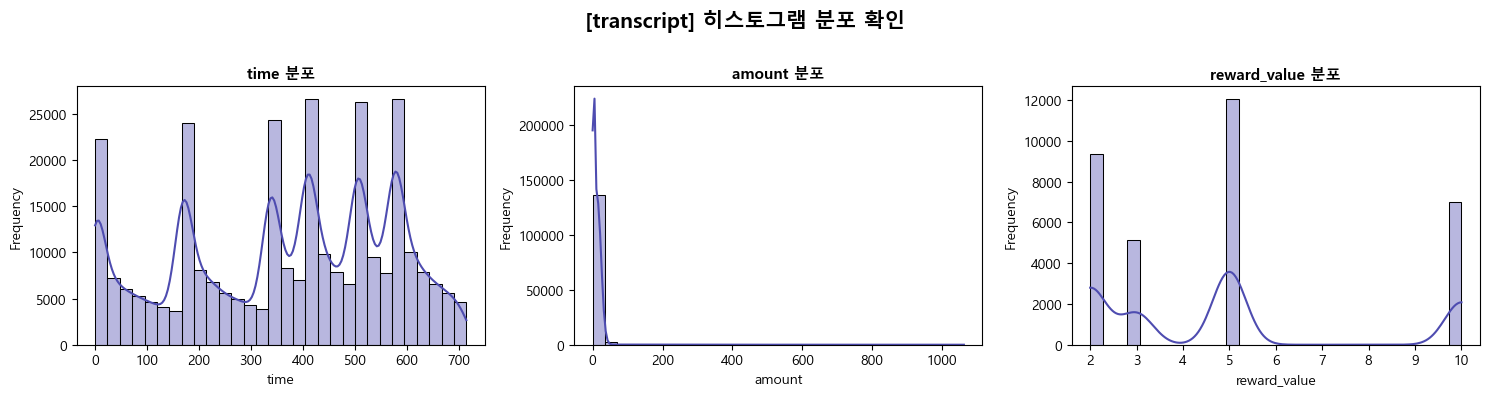

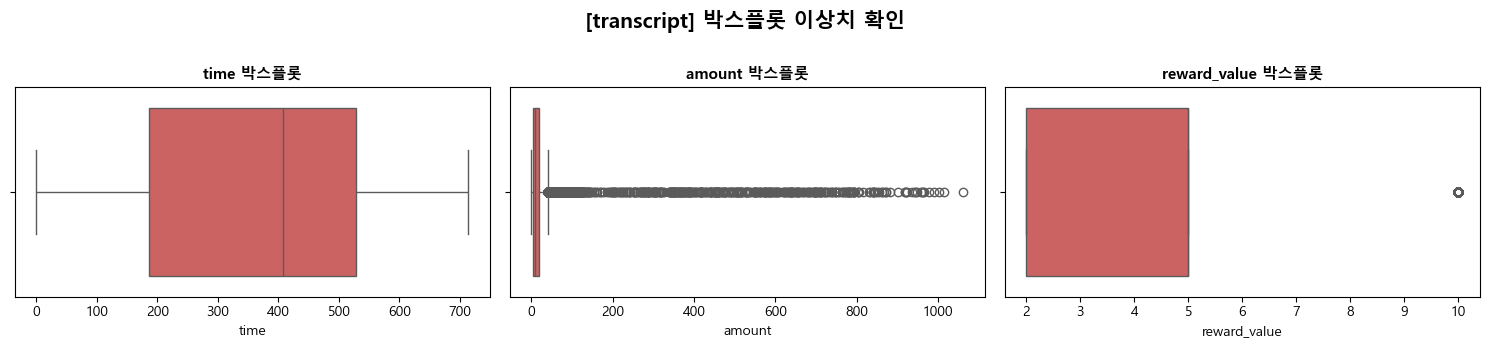

In [106]:
profile_cols = ["time", "amount", "reward_value"]

plot_histograms(df_transcript, profile_cols, "transcript")
plot_boxplots(df_transcript, profile_cols, "transcript")

# 조인키 확인

In [107]:
print("profile id 중복:", df_profile["id"].duplicated().sum())
print("portfolio id 중복:", df_portfolio["id"].duplicated().sum())
print("transcript person이 profile id에 없는 개수:",
      (~df_transcript["person"].isin(df_profile["id"])).sum())

profile id 중복: 0
portfolio id 중복: 0
transcript person이 profile id에 없는 개수: 0


# 스타벅스 데이터 1차 EDA 보고서
본 1차 EDA의 목적은 프로젝트에 사용되는 portfolio, profile, transcript 데이터의 구조를 이해하고,\
결측치·이상치·중복값 여부를 확인하여 이후 문제 정의와 전처리 방향을 설정하는 데 있다.

## 데이터셋 구성
- **portfolio**
    - 크기: 10행 × 6열
    - 역할: 프로모션(오퍼) 자체의 속성을 담고 있는 테이블
    - 주요 컬럼
        - reward : 프로모션 완료 시 고객에게 주는 보상 금액
        - channels : 프로모션이 전달된 채널 목록(web, email, mobile, social)
        - difficulty : 보상을 받기 위해 필요한 최소 지출 금액
        - duration : 프로모션 유효 기간(일 단위)
        - offer_type : 프로모션 유형(bogo, discount, informational)
        - id : 프로모션 고유 ID

- **profile**
    - 크기: 17,000행 × 5열
    - 역할: 고객의 인구통계 및 가입 정보를 담고 있는 테이블
    - 주요 컬럼
        - gender : 고객 성별
        - age : 고객 나이
        - id : 고객 고유 ID ?
        - became_member_on : 멤버십 가입일(YYYYMMDD 형식)
        - income : 고객 연간 소득(달러)

- **transcript**
    - 크기: 306,534행 × 4열
    - 역할: 고객의 프로모션 반응 및 거래 로그를 기록한 이벤트 테이블
    - 주요 컬럼
        - person : 고객 ID
        - event : 이벤트 유형(transaction, offer received, offer viewed, offer completed)
        - value : 이벤트별 세부 정보
        - time : 이벤트 발생 시간

## 테이블별 1차 EDA 결과

### df_portfolio 확인 결과
1) 결측치 및 중복값
    - 결측치 없음
    - 전체 중복 행 없음
    - id 중복 없음

2) 범주 및 값 구조
    - offer_type
        - bogo: 4개
        - discount: 4개
        - informational: 2개
    - channels 조합
        - 'web', 'email', 'mobile', 'social': 4개
        - 'web', 'email', 'mobile': 3개
        - 'email', 'mobile', 'social': 2개
        - 'web', 'email': 1개
    - 수치형 컬럼 기초 통계
        - reward: 평균 4.2, 최솟값 0, 최댓값 10
        - difficulty: 평균 7.7, 최솟값 0, 최댓값 20 
        - duration: 평균 6.5, 최솟값 3, 최댓값 10

3) 해석\


### df_profile 확인 결과
1) 결측치 및 중복값
    - 전체 중복 행: 0
    - id 중복: 0
    - id 제외 중복: 1,237
    - id를 제외한 중복이 존재하지만, 이는 서로 다른 고객이 동일한 속성 조합을 가질 수 있기 때문에\
    즉시 데이터 오류로 판단하기는 어렵다.

2) 결측치 현황
    - gender 결측: 2,175건
    - income 결측: 2,175건

3) 이상치 확인\
age 분포에서 118세가 2,175건으로 매우 많이 등장했다.\
또한 확인 결과 gender, income 결측이면서 age == 118인 행이 동일했다.\
즉, age = 118은 실제 나이라기보다 인구통계 정보가 누락된 대체값 또는 전산 오류로 해석하는것이 타당하다.

4) 해석\
결측치와 age=118이 동일한 행에서 함께 나타난다\
age=118을 실제 이상치로 제거\
결측 대체값으로 간주하고 별도 처리\
두 방법중 한가지를 선택해야 한다.

### df_transcript 확인 결과
1) 이벤트 구조\
df_transcript의 이벤트 분포는 다음과 같다.
    - transaction: 138,953건 (45.33%)
    - offer received: 76,277건 (24.88%)
    - offer viewed: 57,725건 (18.83%)
    - offer completed: 33,579건 (10.95%)
    - transcript는 고객의 구매와 프로모션 반응을 동시에 담고 있는 로그 데이터이며, 이벤트별로 기록되는 정보가 서로 다르다.

2) value 컬럼 구조 확인\
value는 모든 행에서 같은 의미를 가지지 않고, event에 따라 필요한 정보가 다르게 들어가는 구조이다.
    - offer received : 고객이 특정 오퍼를 수신함 또는 확인
        - 예: {'offer id': '...'}
    - offer viewed : 고객이 특정 오퍼를 확인함
        - 예: 예: {'offer id': '...'}
    - offer completed : 고객이 오퍼 조건을 충족하여 완료했고, 보상 정보가 함께 기록됨
        - 예: {'offer_id': '...', 'reward': ...}
    - transaction : 고객의 실제 거래 금액이 기록됨
        - 예: {'amount': ...}

3) value 파싱 후 확인 결과\
또한 전체 테이블 기준으로 보면 결측치가 크게 나타났는데,\
이는 파싱 오류가 아니라 이벤트별로 들어 있는 정보가 다르기 때문이다.

4) 중복값 확인\
df_transcript에서는 완전히 동일한 중복 로그가 존재하며,\
이 중복은 모두 오퍼 완료 이벤트에서 발생했다.
    - 전체 중복 행: 397건
    - 중복 이벤트 유형: 전부 offer completed

### 조인 키 확인 결과
전체 중복 없는것으로 확인

고객 기준 조인은 정상적으로 가능

# 필요 전처리

1. df_profile
    - age=118을 결측 대체값으로 처리할지 검토
    - gender, income 결측과 함께 관리

2. df_transcript
    - offer completed 중복 로그 제거 여부 검토
    - value 파싱 컬럼(offer_id, amount, reward_value)을 기준으로 분석 테이블 정리

In [108]:
## 